# Visual audit of raw AMASS SMPL-H + DMPL poses

This notebook visualizes standard AMASS `*_poses.npz` recordings under `data/amass` without treating pose parameters as Cartesian joints. It uses the same licensed **Extended SMPL+H + DMPL** body-model path and core-11 landmark definitions as `scripts/convert_amass_core11.py`.

The workflow has two layers:

1. **Parameter diagnostics** — always available: archive schema, frame counts, root translation, rotation magnitude, body-pose energy, and DMPL energy.
2. **Anatomical rendering** — requires `AMASS_BODY_MODEL_ROOT`: batched SMPL-H inference, labelled core-11 landmarks over the trusted mesh, body-frame contact sheets, a lightweight skeleton animation, replay checks, and explicit human audit decisions.

Efficiency choices:

- Body-model inference is batched and performed once per recording.
- Dense 6,890-vertex meshes are retained only for six audit frames.
- Animations retain only 22 body joints plus the 11 core landmarks.
- Rendering defaults to 30 Hz even when the source is 120 Hz.

The notebook does not silently declare anatomical correctness. Its last section stays `incomplete` until a reviewer records the required human decisions.

## 1. Configuration

Run from the repository's uv environment:

```bash
export AMASS_BODY_MODEL_ROOT=/path/to/licensed/body_models
uv run --no-sync jupyter lab notebooks/07_visualize_amass_smplh_poses.ipynb
```

The body-model directory must contain:

```text
smplh/female/model.npz
smplh/male/model.npz
dmpls/female/model.npz
dmpls/male/model.npz
```

Set `SAVE_FIGURES = True` only when preserving audit evidence. GIF export is optional and slower than the inline JavaScript animation.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "pyproject.toml").is_file() and (candidate / "scripts").is_dir():
            return candidate
    raise RuntimeError("Could not locate the gavd6 project root from the current directory.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts.convert_amass_core11 import (  # noqa: E402
    CHANNEL_NAMES,
    CORE11_NAMES,
    ConversionConfig,
    HumanBodyPriorBackend,
    SMPLH_JOINT_INDEX,
    SMPLH_VERTEX_INDEX,
    convert_sequence_arrays,
    load_amass_sequence,
    resample_at_times,
    sha256_file,
)

DATA_ROOT = Path(os.environ.get("AMASS_DATA_ROOT", PROJECT_ROOT / "data" / "amass")).expanduser().resolve()
MODEL_ROOT_TEXT = os.environ.get("AMASS_BODY_MODEL_ROOT", "").strip()
BODY_MODEL_ROOT = Path(MODEL_ROOT_TEXT).expanduser().resolve() if MODEL_ROOT_TEXT else None
REPORT_ROOT = Path(os.environ.get("AMASS_VIS_REPORT_ROOT", DATA_ROOT / "visualizations")).expanduser().resolve()

DISPLAY_FPS = 30.0
BATCH_SIZE = 128
CONTACT_FRAME_COUNT = 6
MESH_FACE_STRIDE = 1       # Use 2 only if static mesh rendering is too slow on the current machine.
SHOW_INLINE_ANIMATIONS = True
SAVE_FIGURES = False
SAVE_GIFS = False
WRITE_AUDIT_REPORT = False
DEVICE = os.environ.get("AMASS_VIS_DEVICE", "cuda" if torch.cuda.is_available() else "cpu")

SOURCE_FILES = sorted(DATA_ROOT.rglob("*_poses.npz"))
if not SOURCE_FILES:
    raise FileNotFoundError(f"No *_poses.npz files found under {DATA_ROOT}")

required_models = [] if BODY_MODEL_ROOT is None else [
    BODY_MODEL_ROOT / family / gender / "model.npz"
    for family in ("smplh", "dmpls")
    for gender in ("female", "male")
]
BODY_MODELS_AVAILABLE = bool(required_models) and all(path.is_file() for path in required_models)

print(f"Project root: {PROJECT_ROOT}")
print(f"AMASS data root: {DATA_ROOT}")
print(f"Discovered recordings: {len(SOURCE_FILES)}")
print(f"Device: {DEVICE}")
if BODY_MODELS_AVAILABLE:
    print(f"Licensed body-model root: {BODY_MODEL_ROOT}")
else:
    print("BODY RENDERING DISABLED: set AMASS_BODY_MODEL_ROOT to the licensed model tree shown above.")

Project root: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6
AMASS data root: /Users/theodoremui/dev/alexpose/experiments/sjepa/gavd6/data/amass
Discovered recordings: 2
Device: cpu
BODY RENDERING DISABLED: set AMASS_BODY_MODEL_ROOT to the licensed model tree shown above.


## 2. Discover and validate the recordings

This uses the production converter's loader, so malformed widths, inconsistent frame counts, unsupported gender values, missing keys, and non-finite required shape coefficients fail immediately.

In [2]:
SEQUENCES = {}
inventory_rows = []

for path in SOURCE_FILES:
    sequence = load_amass_sequence(path)
    SEQUENCES[path] = sequence
    finite_frames = (
        np.isfinite(sequence.poses).all(axis=1)
        & np.isfinite(sequence.trans).all(axis=1)
        & np.isfinite(sequence.dmpls).all(axis=1)
    )
    inventory_rows.append(
        {
            "recording": path.relative_to(DATA_ROOT).as_posix(),
            "gender": sequence.gender,
            "native_fps": sequence.mocap_framerate,
            "frames": len(sequence.poses),
            "duration_s": (len(sequence.poses) - 1) / sequence.mocap_framerate,
            "pose_width": sequence.poses.shape[1],
            "betas": len(sequence.betas),
            "dmpl_width": sequence.dmpls.shape[1],
            "finite_frame_fraction": finite_frames.mean(),
            "source_sha256": sha256_file(path),
        }
    )

inventory = pd.DataFrame(inventory_rows)
display(inventory.style.format({"duration_s": "{:.3f}", "finite_frame_fraction": "{:.4f}"}))

assert set(inventory["gender"]) <= {"female", "male"}
assert inventory["pose_width"].eq(156).all()
assert inventory["betas"].eq(16).all()
assert inventory["dmpl_width"].eq(8).all()
assert inventory["finite_frame_fraction"].eq(1.0).all()

,recording,gender,native_fps,frames,duration_s,pose_width,betas,dmpl_width,finite_frame_fraction,source_sha256
0,0004_normal_walk1_poses.npz,female,120.000000,312,2.592,156,16,8,1.0000,79a8dafb0762aa9d76fc7af7c0521435e51b883b8180dab0be4bbfaf8d687c2a
1,0005_normal_walk1_poses.npz,male,120.000000,252,2.092,156,16,8,1.0000,1559133885b692cafc97b744feba547cb7ca372241849ef23026535dce91ebf1


## 3. Parameter-level diagnostics

These plots are useful for detecting discontinuities or malformed archives, but they are **not** anatomical pose renderings. Axis-angle magnitudes and DMPL norms cannot establish correct left/right anatomy.

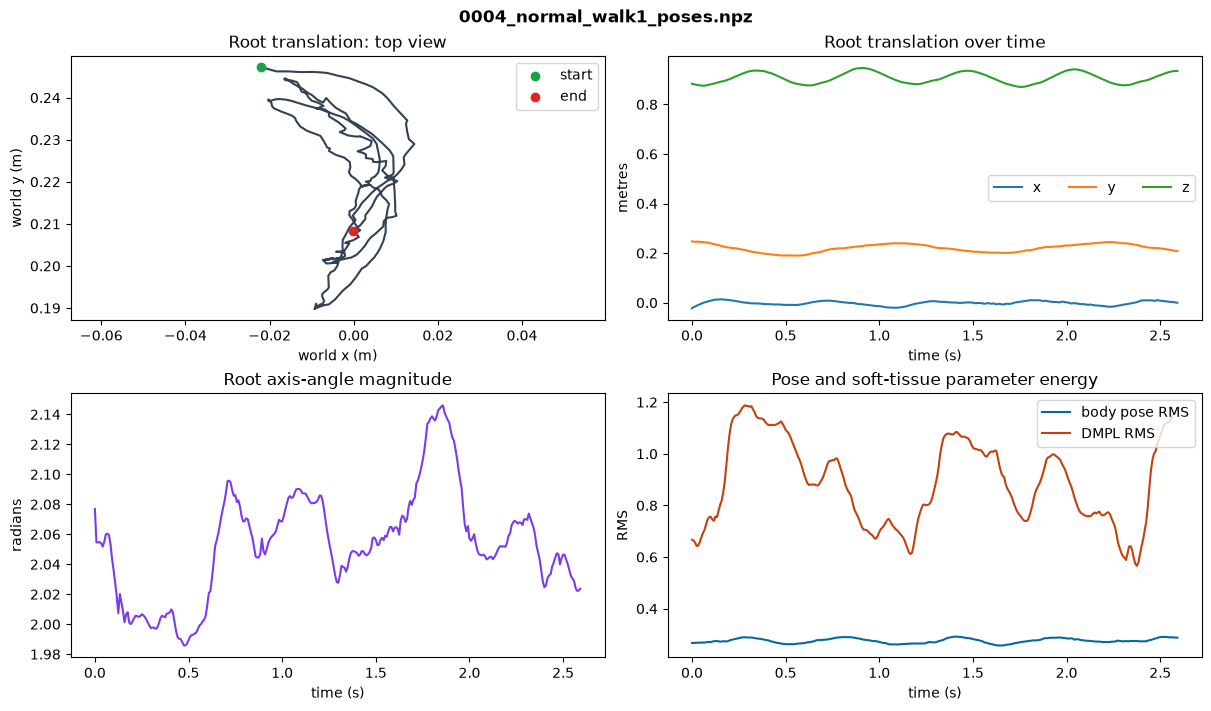

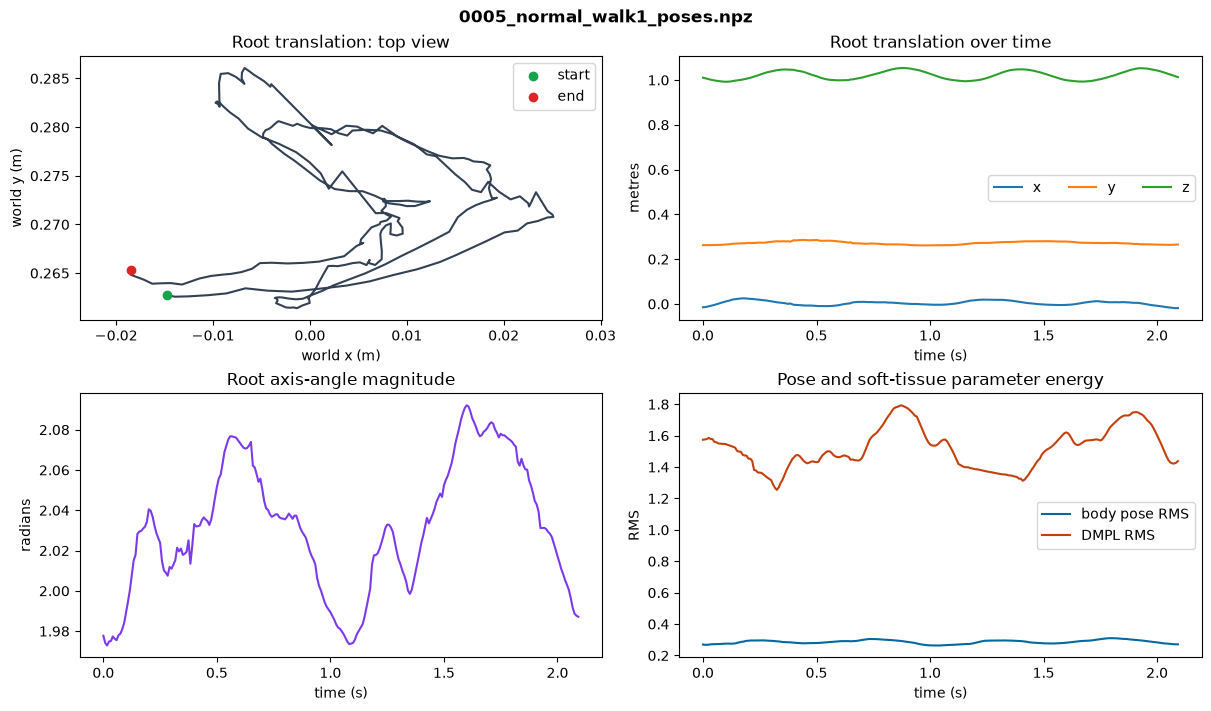

In [3]:
def plot_parameter_diagnostics(path: Path, sequence) -> None:
    time_s = np.arange(len(sequence.poses)) / sequence.mocap_framerate
    root_angle = np.linalg.norm(sequence.poses[:, :3], axis=1)
    body_rms = np.sqrt(np.mean(sequence.poses[:, 3:66] ** 2, axis=1))
    dmpl_rms = np.sqrt(np.mean(sequence.dmpls ** 2, axis=1))

    fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
    fig.suptitle(path.relative_to(DATA_ROOT).as_posix(), fontweight="bold")

    axes[0, 0].plot(sequence.trans[:, 0], sequence.trans[:, 1], color="#334155")
    axes[0, 0].scatter(*sequence.trans[0, :2], color="#16a34a", label="start", zorder=3)
    axes[0, 0].scatter(*sequence.trans[-1, :2], color="#dc2626", label="end", zorder=3)
    axes[0, 0].set(title="Root translation: top view", xlabel="world x (m)", ylabel="world y (m)")
    axes[0, 0].axis("equal")
    axes[0, 0].legend()

    for channel, label in enumerate(("x", "y", "z")):
        axes[0, 1].plot(time_s, sequence.trans[:, channel], label=label)
    axes[0, 1].set(title="Root translation over time", xlabel="time (s)", ylabel="metres")
    axes[0, 1].legend(ncol=3)

    axes[1, 0].plot(time_s, root_angle, color="#7c3aed")
    axes[1, 0].set(title="Root axis-angle magnitude", xlabel="time (s)", ylabel="radians")

    axes[1, 1].plot(time_s, body_rms, label="body pose RMS", color="#0369a1")
    axes[1, 1].plot(time_s, dmpl_rms, label="DMPL RMS", color="#c2410c")
    axes[1, 1].set(title="Pose and soft-tissue parameter energy", xlabel="time (s)", ylabel="RMS")
    axes[1, 1].legend()
    plt.show()


for source_path, source_sequence in SEQUENCES.items():
    plot_parameter_diagnostics(source_path, source_sequence)

## 4. Batched SMPL-H + DMPL rendering

The renderer uses all 16 shape coefficients, all 8 DMPL coefficients, the 63-dimensional body pose, the 90-dimensional hand pose, root orientation, and translation. It retains:

- all native-rate core-11 coordinates for exact converter diagnostics;
- 22 compact body joints at display frames for animation;
- full meshes only at six contact-sheet frames.

The mesh overlay is the trusted anatomical reference: core landmarks are labelled directly on the official SMPL-H topology rather than inferred from an unlabelled stick figure.

In [4]:
BODY_JOINT_NAMES = (
    "pelvis", "left_hip", "right_hip", "spine1", "left_knee", "right_knee",
    "spine2", "left_ankle", "right_ankle", "spine3", "left_foot", "right_foot",
    "neck", "left_collar", "right_collar", "head", "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow", "left_wrist", "right_wrist",
)
BODY_EDGES = (
    (0, 1), (0, 2), (0, 3), (1, 4), (2, 5), (3, 6), (4, 7), (5, 8),
    (6, 9), (7, 10), (8, 11), (9, 12), (12, 13), (12, 14), (12, 15),
    (13, 16), (14, 17), (16, 18), (17, 19), (18, 20), (19, 21),
)
CORE_EDGES_LEFT = ((0, 1), (1, 3), (3, 5), (5, 7), (5, 9))
CORE_EDGES_RIGHT = ((0, 2), (2, 4), (4, 6), (6, 8), (6, 10))
CORE_LABELS = ("P", "LH", "RH", "LK", "RK", "LA", "RA", "LHeel", "RHeel", "LFore", "RFore")
LEFT_COLOR = "#dc2626"
RIGHT_COLOR = "#2563eb"
PELVIS_COLOR = "#111827"


@dataclass
class RenderedRecording:
    path: Path
    sequence: Any
    display_indices: np.ndarray
    display_times_s: np.ndarray
    core_world: np.ndarray
    valid: np.ndarray
    body_joints_world: np.ndarray
    mesh_vertices_world: dict[int, np.ndarray]
    faces: np.ndarray


BACKEND = (
    HumanBodyPriorBackend(BODY_MODEL_ROOT, DEVICE, BATCH_SIZE)
    if BODY_MODELS_AVAILABLE
    else None
)


def get_body_model(gender: str):
    if not BODY_MODELS_AVAILABLE:
        raise RuntimeError("Set AMASS_BODY_MODEL_ROOT before running anatomical rendering cells.")
    # Reuse the production converter's cached loader and validation checks so
    # visualization cannot silently select a different model family or layout.
    return BACKEND._load_model(gender)


def core11_from_result(result):
    joints, vertices = result.Jtr, result.v
    return torch.stack(
        [
            joints[:, SMPLH_JOINT_INDEX["pelvis"]],
            joints[:, SMPLH_JOINT_INDEX["left_hip"]],
            joints[:, SMPLH_JOINT_INDEX["right_hip"]],
            joints[:, SMPLH_JOINT_INDEX["left_knee"]],
            joints[:, SMPLH_JOINT_INDEX["right_knee"]],
            joints[:, SMPLH_JOINT_INDEX["left_ankle"]],
            joints[:, SMPLH_JOINT_INDEX["right_ankle"]],
            vertices[:, SMPLH_VERTEX_INDEX["left_heel"]],
            vertices[:, SMPLH_VERTEX_INDEX["right_heel"]],
            0.5 * (vertices[:, SMPLH_VERTEX_INDEX["left_big_toe"]] + vertices[:, SMPLH_VERTEX_INDEX["left_small_toe"]]),
            0.5 * (vertices[:, SMPLH_VERTEX_INDEX["right_big_toe"]] + vertices[:, SMPLH_VERTEX_INDEX["right_small_toe"]]),
        ],
        dim=1,
    )


def display_frame_indices(frame_count: int, native_fps: float, display_fps: float) -> np.ndarray:
    duration = (frame_count - 1) / native_fps
    times = np.arange(0.0, duration + 1e-10, 1.0 / display_fps)
    return np.unique(np.clip(np.rint(times * native_fps).astype(int), 0, frame_count - 1))


def render_recording(path: Path, sequence) -> RenderedRecording:
    model = get_body_model(sequence.gender)
    device = torch.device(DEVICE)
    frame_count = len(sequence.poses)
    show_indices = display_frame_indices(frame_count, sequence.mocap_framerate, DISPLAY_FPS)
    contact_positions = np.unique(np.rint(np.linspace(0, len(show_indices) - 1, CONTACT_FRAME_COUNT)).astype(int))
    contact_indices = set(show_indices[contact_positions].tolist())
    show_lookup = {int(native): position for position, native in enumerate(show_indices)}

    core_world = np.zeros((frame_count, len(CORE11_NAMES), 3), dtype=np.float32)
    valid = np.zeros((frame_count, len(CORE11_NAMES)), dtype=bool)
    body_joints = np.zeros((len(show_indices), len(BODY_JOINT_NAMES), 3), dtype=np.float32)
    meshes = {}

    for start in range(0, frame_count, BATCH_SIZE):
        stop = min(start + BATCH_SIZE, frame_count)
        sl = slice(start, stop)
        poses = torch.from_numpy(sequence.poses[sl]).to(device)
        trans = torch.from_numpy(sequence.trans[sl]).to(device)
        dmpls = torch.from_numpy(sequence.dmpls[sl]).to(device)
        betas = torch.from_numpy(np.repeat(sequence.betas[None, :], stop - start, axis=0)).to(device)

        with torch.inference_mode():
            result = model(
                root_orient=poses[:, 0:3],
                pose_body=poses[:, 3:66],
                pose_hand=poses[:, 66:156],
                betas=betas,
                dmpls=dmpls,
                trans=trans,
            )
            core = core11_from_result(result)

        chunk = core.detach().cpu().numpy().astype(np.float32, copy=False)
        chunk_valid = np.isfinite(chunk).all(axis=2)
        chunk_valid &= chunk_valid[:, 0:1]
        chunk[~chunk_valid] = 0.0
        core_world[sl] = chunk
        valid[sl] = chunk_valid

        interesting = [idx for idx in range(start, stop) if idx in show_lookup]
        for native_index in interesting:
            local_index = native_index - start
            body_joints[show_lookup[native_index]] = (
                result.Jtr[local_index, : len(BODY_JOINT_NAMES)].detach().cpu().numpy()
            )
            if native_index in contact_indices:
                meshes[native_index] = result.v[local_index].detach().cpu().numpy().astype(np.float32)

    faces_value = model.f.detach().cpu().numpy() if torch.is_tensor(model.f) else np.asarray(model.f)
    return RenderedRecording(
        path=path,
        sequence=sequence,
        display_indices=show_indices,
        display_times_s=show_indices / sequence.mocap_framerate,
        core_world=core_world,
        valid=valid,
        body_joints_world=body_joints,
        mesh_vertices_world=meshes,
        faces=faces_value.astype(np.int32),
    )

In [5]:
RENDERED = {}
if BODY_MODELS_AVAILABLE:
    for source_path, source_sequence in SEQUENCES.items():
        print(f"Rendering {source_path.name} ({len(source_sequence.poses)} native frames) ...")
        RENDERED[source_path] = render_recording(source_path, source_sequence)
    print("Rendering complete.")
else:
    print("Skipped SMPL-H rendering because the licensed body-model files are unavailable.")

Skipped SMPL-H rendering because the licensed body-model files are unavailable.


## 5. Reproduce the converter geometry and quantify the audit

This section applies the exact frozen 30 Hz conversion contract to the newly rendered core landmarks. Replay error compares reconstructed world coordinates with an independently resampled copy of the raw world-space landmarks.

`forefoot_ahead_*` is a useful facing-sign diagnostic: positive values mean the labelled forefoot is ahead of the same-side heel along the selected forward axis. It supports—but does not replace—visual inspection.

In [6]:
CONVERTED = {}
audit_rows = []
manifest_path = PROJECT_ROOT / "manifests" / "amass_core11_conversion_smoke.csv"
manifest = pd.read_csv(manifest_path) if manifest_path.is_file() else pd.DataFrame()

for source_path, rendered in RENDERED.items():
    converted = convert_sequence_arrays(
        rendered.core_world,
        rendered.valid,
        source_fps=rendered.sequence.mocap_framerate,
        config=ConversionConfig(canonical_fps=30.0, batch_size=BATCH_SIZE),
    )
    CONVERTED[source_path] = converted

    coordinates = converted["coordinates"]
    coordinates_m = converted["coordinates_m"]
    frame = converted["frame"]
    canonical_world, canonical_valid = resample_at_times(
        rendered.core_world,
        rendered.valid,
        source_fps=rendered.sequence.mocap_framerate,
        target_times=converted["canonical_times_s"],
    )
    replay = coordinates_m @ frame.world_to_body_transform + converted["pelvis_world_m"][:, None, :]

    row = {
        "recording": source_path.name,
        "gender": rendered.sequence.gender,
        "canonical_shape": str(coordinates.shape),
        "valid_fraction": float(converted["valid"].mean()),
        "pelvis_center_max_abs": float(np.abs(coordinates[:, 0]).max()),
        "world_replay_max_error_m": float(np.abs(replay - canonical_world).max()),
        "forward_method": frame.method,
        "travel_displacement_m": frame.displacement_m,
        "travel_straightness": frame.straightness,
        "travel_linearity": frame.linearity,
        "lateral_hip_alignment": frame.lateral_hip_alignment,
        "leg_length_m": converted["leg_length_m"],
        "left_forefoot_ahead_m": float(np.median(coordinates_m[:, 9, 0] - coordinates_m[:, 7, 0])),
        "right_forefoot_ahead_m": float(np.median(coordinates_m[:, 10, 0] - coordinates_m[:, 8, 0])),
    }

    if not manifest.empty:
        match = manifest[manifest["relative_path"].astype(str).str.endswith(source_path.name)]
        if len(match) == 1 and BODY_MODEL_ROOT is not None:
            expected = match.iloc[0]
            row["manifest_gender_match"] = expected["gender"] == rendered.sequence.gender
            row["body_model_hash_match"] = sha256_file(
                BODY_MODEL_ROOT / "smplh" / rendered.sequence.gender / "model.npz"
            ) == expected["body_model_sha256"]
            row["dmpl_model_hash_match"] = sha256_file(
                BODY_MODEL_ROOT / "dmpls" / rendered.sequence.gender / "model.npz"
            ) == expected["dmpl_model_sha256"]

    audit_rows.append(row)

audit = pd.DataFrame(audit_rows)
if len(audit):
    display(audit.T)
    assert audit["valid_fraction"].eq(1.0).all()
    assert audit["pelvis_center_max_abs"].lt(1e-6).all()
    assert audit["world_replay_max_error_m"].lt(2e-6).all()
    if "body_model_hash_match" in audit:
        assert audit[["manifest_gender_match", "body_model_hash_match", "dmpl_model_hash_match"]].all().all()
else:
    print("No anatomical audit table until SMPL-H rendering is enabled.")

No anatomical audit table until SMPL-H rendering is enabled.


## 6. Labelled mesh contact sheets

Each mesh is transformed into the converter's trial-level body frame and centered at the pelvis:

- **plot x:** mediolateral, positive toward anatomical left;
- **plot y:** forward;
- **plot z:** vertical up;
- **red:** labelled anatomical-left core chain;
- **blue:** labelled anatomical-right core chain.

The camera looks toward the front of the body with a slight elevation. Inspect all six time points; a single plausible frame cannot establish a coherent sequence.

In [7]:
def to_plot_axes(body_xyz: np.ndarray) -> np.ndarray:
    # Stored [forward, up, lateral] -> plotted [lateral, forward, up].
    return body_xyz[..., [2, 0, 1]]


def transform_world_points(points: np.ndarray, pelvis_world: np.ndarray, frame) -> np.ndarray:
    return (points - pelvis_world) @ frame.world_to_body_transform.T


def set_equal_3d_limits(ax, points: np.ndarray, padding: float = 0.08) -> None:
    lower = np.nanmin(points, axis=0)
    upper = np.nanmax(points, axis=0)
    center = 0.5 * (lower + upper)
    radius = 0.5 * float(np.max(upper - lower)) * (1.0 + padding)
    radius = max(radius, 0.25)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_box_aspect((1, 1, 1))


def plot_core_edges(ax, points: np.ndarray) -> None:
    for edge in CORE_EDGES_LEFT:
        ax.plot(*points[list(edge)].T, color=LEFT_COLOR, linewidth=2.2)
    for edge in CORE_EDGES_RIGHT:
        ax.plot(*points[list(edge)].T, color=RIGHT_COLOR, linewidth=2.2)
    ax.scatter(*points[1::2].T, color=LEFT_COLOR, s=18, depthshade=False)
    ax.scatter(*points[2::2].T, color=RIGHT_COLOR, s=18, depthshade=False)
    ax.scatter(*points[0].T, color=PELVIS_COLOR, s=22, depthshade=False)


def labelled_mesh_contact_sheet(rendered: RenderedRecording, converted: dict[str, Any]):
    frame = converted["frame"]
    native_indices = sorted(rendered.mesh_vertices_world)
    transformed_meshes = []
    transformed_cores = []
    for native_index in native_indices:
        pelvis = rendered.core_world[native_index, 0]
        transformed_meshes.append(
            to_plot_axes(transform_world_points(rendered.mesh_vertices_world[native_index], pelvis, frame))
        )
        transformed_cores.append(
            to_plot_axes(transform_world_points(rendered.core_world[native_index], pelvis, frame))
        )

    all_points = np.concatenate(transformed_meshes, axis=0)
    columns = 3
    rows = int(np.ceil(len(native_indices) / columns))
    fig = plt.figure(figsize=(15, 4.8 * rows), constrained_layout=True)
    fig.suptitle(
        f"{rendered.path.name} | {rendered.sequence.gender} | {frame.method}\n"
        "red = anatomical left, blue = anatomical right; x = +left, y = +forward, z = +up",
        fontweight="bold",
    )

    for panel, (native_index, mesh, core) in enumerate(
        zip(native_indices, transformed_meshes, transformed_cores), start=1
    ):
        ax = fig.add_subplot(rows, columns, panel, projection="3d")
        triangles = mesh[rendered.faces[::MESH_FACE_STRIDE]]
        surface = Poly3DCollection(triangles, facecolor="#cbd5e1", edgecolor="none", alpha=0.28)
        ax.add_collection3d(surface)
        plot_core_edges(ax, core)
        for label, point in zip(CORE_LABELS, core):
            ax.text(*point, label, fontsize=6, color="#111827")
        set_equal_3d_limits(ax, all_points)
        # Camera sits on the +forward side and looks back toward the body: a true front view.
        ax.view_init(elev=8, azim=90)
        ax.set(
            title=f"frame {native_index} | {native_index / rendered.sequence.mocap_framerate:.2f} s",
            xlabel="+left (m)",
            ylabel="+forward (m)",
            zlabel="+up (m)",
        )

    if SAVE_FIGURES:
        REPORT_ROOT.mkdir(parents=True, exist_ok=True)
        destination = REPORT_ROOT / f"{rendered.path.stem}_labelled_mesh.png"
        fig.savefig(destination, dpi=180, bbox_inches="tight")
        print(f"Saved {destination}")
    plt.show()


for source_path, rendered in RENDERED.items():
    labelled_mesh_contact_sheet(rendered, CONVERTED[source_path])

## 7. Lightweight body-frame animations

The animation overlays the full 22-joint body skeleton in grey and the core-11 chains in red/blue. It uses the same constant trial-level body frame as conversion, while re-centering each frame at its pelvis. This makes limb labelling and forward orientation easier to inspect without camera motion from root translation.

In [8]:
ANIMATIONS = {}


def body_frame_animation(rendered: RenderedRecording, converted: dict[str, Any]):
    frame = converted["frame"]
    native_indices = rendered.display_indices
    pelvis = rendered.core_world[native_indices, 0]
    body = to_plot_axes(transform_world_points(rendered.body_joints_world, pelvis[:, None, :], frame))
    core = to_plot_axes(transform_world_points(rendered.core_world[native_indices], pelvis[:, None, :], frame))
    limits_source = np.concatenate([body.reshape(-1, 3), core.reshape(-1, 3)], axis=0)

    fig = plt.figure(figsize=(7.5, 7))
    ax = fig.add_subplot(111, projection="3d")
    set_equal_3d_limits(ax, limits_source)
    # Three-quarter front view from the +forward side.
    ax.view_init(elev=10, azim=70)
    ax.set(xlabel="+left (m)", ylabel="+forward (m)", zlabel="+up (m)")

    body_lines = [ax.plot([], [], [], color="#94a3b8", linewidth=1.2)[0] for _ in BODY_EDGES]
    left_lines = [ax.plot([], [], [], color=LEFT_COLOR, linewidth=2.5)[0] for _ in CORE_EDGES_LEFT]
    right_lines = [ax.plot([], [], [], color=RIGHT_COLOR, linewidth=2.5)[0] for _ in CORE_EDGES_RIGHT]
    pelvis_point = ax.plot([], [], [], marker="o", linestyle="", color=PELVIS_COLOR, markersize=5)[0]
    left_points = ax.plot([], [], [], marker="o", linestyle="", color=LEFT_COLOR, markersize=4)[0]
    right_points = ax.plot([], [], [], marker="o", linestyle="", color=RIGHT_COLOR, markersize=4)[0]

    def update(position: int):
        for artist, edge in zip(body_lines, BODY_EDGES):
            values = body[position, list(edge)]
            artist.set_data_3d(values[:, 0], values[:, 1], values[:, 2])
        for artist, edge in zip(left_lines, CORE_EDGES_LEFT):
            values = core[position, list(edge)]
            artist.set_data_3d(values[:, 0], values[:, 1], values[:, 2])
        for artist, edge in zip(right_lines, CORE_EDGES_RIGHT):
            values = core[position, list(edge)]
            artist.set_data_3d(values[:, 0], values[:, 1], values[:, 2])
        pelvis_point.set_data_3d(*core[position, 0].reshape(3, 1))
        left_points.set_data_3d(*core[position, 1::2].T)
        right_points.set_data_3d(*core[position, 2::2].T)
        ax.set_title(
            f"{rendered.path.name}\nframe {native_indices[position]} | "
            f"{rendered.display_times_s[position]:.2f} s | {frame.method}"
        )
        return (*body_lines, *left_lines, *right_lines, pelvis_point, left_points, right_points)

    animation = FuncAnimation(
        fig,
        update,
        frames=len(native_indices),
        interval=1000.0 / DISPLAY_FPS,
        blit=False,
        repeat=True,
    )
    plt.close(fig)

    if SAVE_GIFS:
        REPORT_ROOT.mkdir(parents=True, exist_ok=True)
        destination = REPORT_ROOT / f"{rendered.path.stem}_body_frame.gif"
        animation.save(destination, writer=PillowWriter(fps=DISPLAY_FPS), dpi=100)
        print(f"Saved {destination}")
    return animation


for source_path, rendered in RENDERED.items():
    animation = body_frame_animation(rendered, CONVERTED[source_path])
    ANIMATIONS[source_path] = animation  # Retain a reference so Matplotlib does not garbage-collect it.
    if SHOW_INLINE_ANIMATIONS:
        display(HTML(animation.to_jshtml(fps=DISPLAY_FPS, default_mode="loop")))

## 8. Required human audit decisions

For every recording, examine the labelled mesh contact sheet and the complete animation before filling this table. Use only `pass` or `fail`; leave an item as `None` when evidence is incomplete.

Required decisions:

1. The installed gender-specific SMPL-H and DMPL hashes match the conversion manifest.
2. Leg length is plausible and nonzero.
3. The pelvis remains centered at zero in body-frame coordinates.
4. Forward is not visibly reversed for the ordinary walk.
5. Hip, knee, ankle, heel, and forefoot remain on the labelled anatomical-left chain.
6. The corresponding joints remain on the labelled anatomical-right chain.
7. The reconstructed motion is finite, smooth, and visually coherent.
8. The hip-facing fallback is understood rather than ignored.
9. The labelled mesh agrees with an official AMASS rendering or this trusted official SMPL-H topology rendering.

Numerical reflection tests cannot detect a recording mirrored consistently from beginning to end. Human laterality review is mandatory.

In [9]:
REQUIRED_HUMAN_CHECKS = (
    "gender_specific_model_hashes",
    "leg_length_plausible",
    "pelvis_centered",
    "forward_not_reversed",
    "left_chain_anatomically_correct",
    "right_chain_anatomically_correct",
    "world_motion_visually_coherent",
    "hip_facing_fallback_understood",
    "trusted_rendering_agrees",
)

# Fill these only after viewing every contact-sheet frame and the full animation.
MANUAL_AUDIT = {
    path.name: {
        "checks": {name: None for name in REQUIRED_HUMAN_CHECKS},
        "notes": "",
        "reviewer": "",
    }
    for path in SOURCE_FILES
}

# Example after review:
# MANUAL_AUDIT["0004_normal_walk1_poses.npz"]["checks"]["forward_not_reversed"] = "pass"
# MANUAL_AUDIT["0004_normal_walk1_poses.npz"]["notes"] = "Forefeet remain ahead of heels; labelled chains match mesh."
MANUAL_AUDIT

{'0004_normal_walk1_poses.npz': {'checks': {'gender_specific_model_hashes': None,
   'leg_length_plausible': None,
   'pelvis_centered': None,
   'forward_not_reversed': None,
   'left_chain_anatomically_correct': None,
   'right_chain_anatomically_correct': None,
   'world_motion_visually_coherent': None,
   'hip_facing_fallback_understood': None,
   'trusted_rendering_agrees': None},
  'notes': '',
  'reviewer': ''},
 '0005_normal_walk1_poses.npz': {'checks': {'gender_specific_model_hashes': None,
   'leg_length_plausible': None,
   'pelvis_centered': None,
   'forward_not_reversed': None,
   'left_chain_anatomically_correct': None,
   'right_chain_anatomically_correct': None,
   'world_motion_visually_coherent': None,
   'hip_facing_fallback_understood': None,
   'trusted_rendering_agrees': None},
  'notes': '',
  'reviewer': ''}}

In [10]:
def summarize_manual_audit(decisions: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for recording, record in decisions.items():
        values = list(record["checks"].values())
        invalid = [value for value in values if value not in {None, "pass", "fail"}]
        if invalid:
            raise ValueError(f"{recording} contains invalid decisions: {invalid}")
        status = "fail" if "fail" in values else ("pass" if all(value == "pass" for value in values) else "incomplete")
        rows.append(
            {
                "recording": recording,
                "status": status,
                "passed": sum(value == "pass" for value in values),
                "failed": sum(value == "fail" for value in values),
                "pending": sum(value is None for value in values),
                "reviewer": record["reviewer"],
                "notes": record["notes"],
            }
        )
    return pd.DataFrame(rows)


manual_summary = summarize_manual_audit(MANUAL_AUDIT)
display(manual_summary)

if WRITE_AUDIT_REPORT:
    REPORT_ROOT.mkdir(parents=True, exist_ok=True)
    report = {
        "schema": "amass-core11-visual-audit-v1",
        "data_root": str(DATA_ROOT),
        "body_model_root": str(BODY_MODEL_ROOT) if BODY_MODEL_ROOT else None,
        "device": DEVICE,
        "automatic_audit": audit_rows,
        "manual_audit": MANUAL_AUDIT,
    }
    destination = REPORT_ROOT / "amass_core11_smoke_visual_audit.json"
    destination.write_text(json.dumps(report, indent=2, default=str) + "\n", encoding="utf-8")
    print(f"Saved {destination}")

if not manual_summary["status"].eq("pass").all():
    print("INCOMPLETE: do not promote the smoke contract until every required human check passes.")
else:
    print("PASS: all automatic and required human visual checks are recorded as passing.")

,recording,status,passed,failed,pending,reviewer,notes
0,0004_normal_walk1_poses.npz,incomplete,0,0,9,,
1,0005_normal_walk1_poses.npz,incomplete,0,0,9,,


INCOMPLETE: do not promote the smoke contract until every required human check passes.


## Reading key

- A structurally valid render is not automatically anatomically correct.
- For a front-facing body, the subject's anatomical left appears on the viewer's right; rely on the red/blue labels rather than screen intuition.
- Brief foot crossing can be normal. Judge chain identity across time, not by requiring every left point to remain on one side of the global image.
- A positive median forefoot-minus-heel forward offset supports the facing direction, but only the labelled mesh and full motion can resolve an ambiguous fallback.
- If a check fails, preserve the image, animation, manifest row, and notes. Do not overwrite or relabel the source to force a pass.